# Long-Term Trend Analysis of Pettitt-Derived Melt Dates (1988–2022)
This section analyzes the 35-year trends in Pettitt-derived MOD, MED, and melt duration. Trend significance was evaluated using the Mann–Kendall test, and the magnitude of change was quantified using Sen’s slope. To ensure the robustness of long-term trends, the analysis was restricted to pixels with valid data for at least 30 out of the 35 years.

Although a significance level of 0.05 is commonly recommended, a more relaxed threshold of 0.2 was applied in this analysis to better visualize the spatial distribution of trend patterns.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import linregress, spearmanr
from pymannkendall import original_test
import matplotlib.colors as mcolors
from scipy.stats import kendalltau

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

## Create the land mask for regions north of 60°N

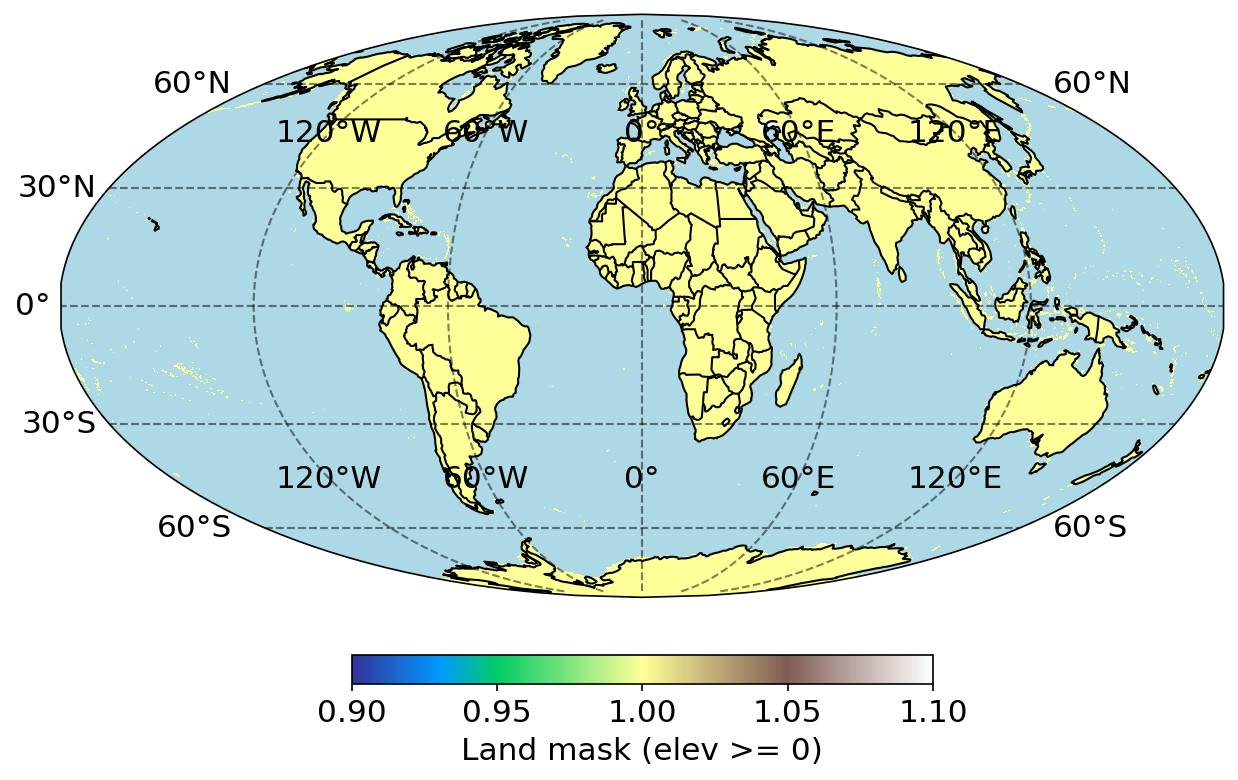

In [2]:
# Create land mask using DEM
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

DEM_path = '/home/nayoung/nas_data/DEM'
Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))
DEM_25km = nc.Dataset(Find_DEM_File[0])
with nc.Dataset(Find_DEM_File[0]) as ds:
    DEM_elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

land_mask = DEM_elev > 0
land_only = np.where(land_mask, 1, np.nan)

# Check the land mask for the entire world
hPlot.plot_map(domain_lon, domain_lat, land_only, np.nanmin(land_only), 1, plot_title="Land mask (elev >= 0)", label_title="Land mask (elev >= 0)", cmap='terrain')

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = DEM_elev.filled(np.nan)  
elev_60N = elev_np[lat_mask_idx, :]

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8) 

## Create a function to plot the North Polar region, as the study focuses on areas north of 60°N

In [3]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = mcolors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='both',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax

## Load the data

In [4]:
Pettitt_MOD_file_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MOD_pettitt_250window_MA5_meanstd_1988_2022.nc'
PettittMED_file_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MED_pettitt_250window_MA5_meanstd_1988_2022.nc'
TB_cluster_map_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc'
permafrost_mask_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Permafrost_waterbody_mask'

with nc.Dataset(Pettitt_MOD_file_path) as ds:
    MOD_doy = ds.variables['MOD_doy'][:]
    Tau = ds.variables['tau'][:]
    lon = ds.variables['lon'][:]
    lat = ds.variables['lat'][:]

with nc.Dataset(PettittMED_file_path) as ds:
    MED_doy = ds.variables['MED_doy'][:]

with nc.Dataset(TB_cluster_map_path) as ds:
    TB_cluster = ds.variables['TB_cluster'][:]  # (lat, lon)

## Define the functions required for the analysis

In [5]:
def load_mask_for_year(y):
    yfile = 1992 if y <= 1992 else y
    fpath = f"{permafrost_mask_path}/Permafrost_waterbody_mask_25km_{yfile}.nc"
    with nc.Dataset(fpath) as ds:
        snowice_mask = ds.variables['snowice_mask'][:]
        waterbody_mask = ds.variables['water_mask'][:]
    mask = np.isfinite(snowice_mask) & np.isfinite(waterbody_mask)
    return mask.astype(np.uint8)


def mann_kendall_test(y):
    """
    Returns tau, p-value
    """
    x = np.arange(len(y))
    mask = np.isfinite(y)
    if np.sum(mask) < 5:
        return np.nan, np.nan
    tau, p = kendalltau(x[mask], y[mask])
    return tau, p


def sens_slope(y):
    """
    Sen's slope (days/year)
    """
    mask = np.isfinite(y)
    y = y[mask]
    x = np.arange(len(y))

    if len(y) < 5:
        return np.nan

    slopes = []
    for i in range(len(y)-1):
        for j in range(i+1, len(y)):
            slopes.append((y[j] - y[i]) / (j - i))
    return np.median(slopes)

## 1. MOD Trend Analysis

In [6]:
# Define the start and end year
start_year, end_year = 1988, 2022
min_years = 30

if np.ma.isMaskedArray(MOD_doy):
    MOD_doy = MOD_doy.filled(np.nan)
MOD_doy = np.array(MOD_doy, dtype=np.float32, copy=True)

# Exclude cluster 3 globally
MOD_doy[TB_cluster == 3, :] = np.nan

# Analysis was restricted to DOY between 30 and 250.
MOD_doy[(MOD_doy < 30) | (MOD_doy > 250)] = np.nan

for yi, year in enumerate(range(start_year, end_year+1)):
    bad = (load_mask_for_year(year) == 0)
    slice_y = MOD_doy[:, :, yi]
    slice_y[bad] = np.nan
    MOD_doy[:, :, yi] = slice_y

lat_n, lon_n = MOD_doy.shape[:2]
mk_tau   = np.full((lat_n, lon_n), np.nan)
mk_p     = np.full((lat_n, lon_n), np.nan)
mk_trend = np.full((lat_n, lon_n), 0, dtype=np.int8)  
mk_slope = np.full((lat_n, lon_n), np.nan)            # Sen’s slope (days/year)

for i in range(lat_n):
    for j in range(lon_n):
        series = MOD_doy[i, j, :]
        valid = ~np.isnan(series)
        if np.count_nonzero(valid) < min_years:
            continue
        try:
            res = original_test(series[valid])
            mk_tau[i, j]   = res.Tau
            mk_p[i, j]     = res.p
            mk_trend[i, j] = 1 if res.trend == 'increasing' else (-1 if res.trend == 'decreasing' else 0)
            mk_slope[i, j] = res.slope      
        except Exception:
            pass

### Figure 9a. Sen’s slope of Pettitt-derived MOD, shown only for pixels significant at the 80% confidence level (p < 0.2)

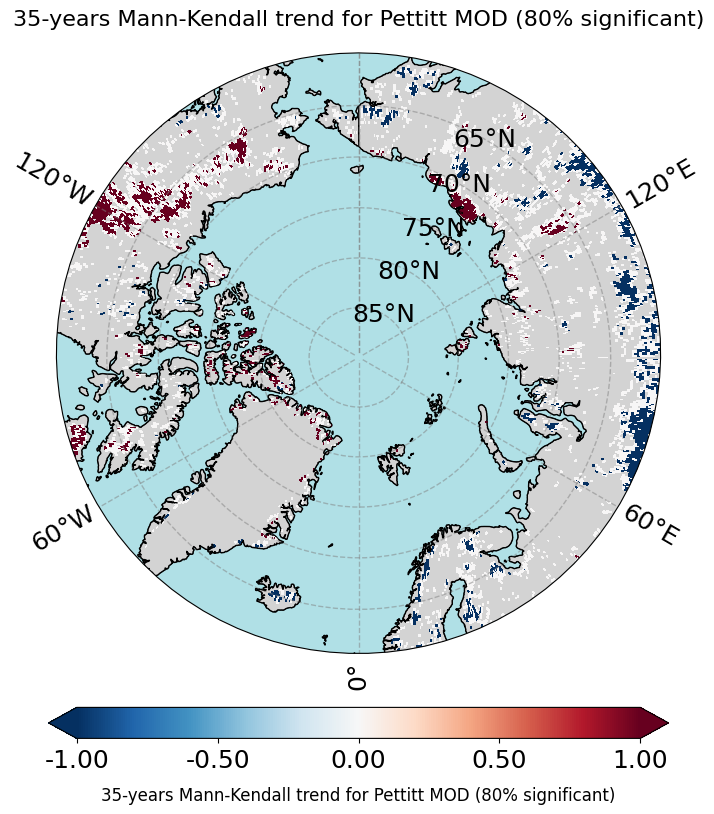

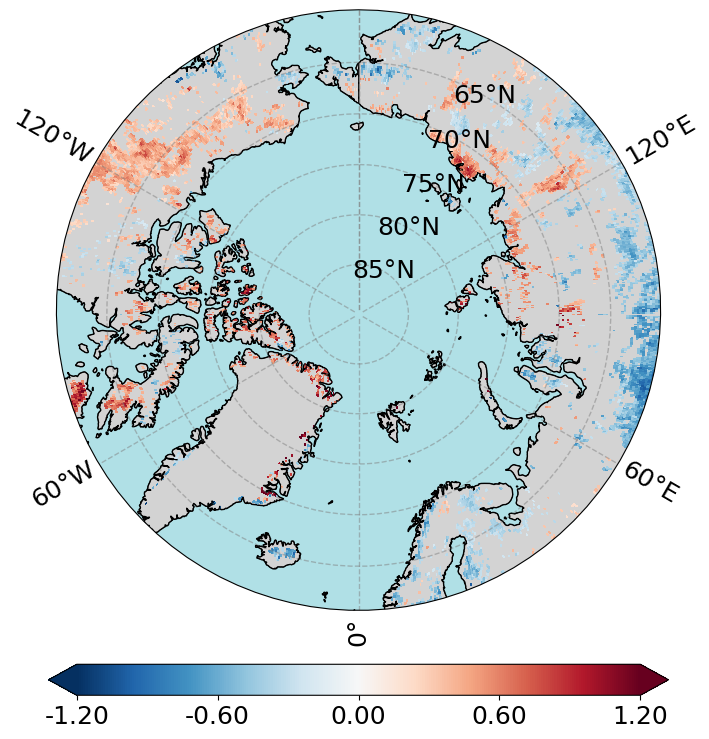

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/MOD_Senslope_80percent.png
Mean slope for 80% significant MOD (days/year):  0.02317430422258536
Median slope for 80% significant MOD (days/year):  0.25
Total significant pixels: 10040
Decreasing pixels: 1762
Increasing pixels: 1665
No-trend pixels: 6613


In [7]:
domain_lon, domain_lat = np.meshgrid(lon, lat)

# 1. Plot trend with only 80% significant level
significant_level = 0.2
confidence_level = int((1 - significant_level)*100)
mk_trend_significant = np.where(mk_p < significant_level, mk_trend, np.nan)
plot_Northpole(domain_lon, domain_lat, mk_trend_significant, label_title = f'35-years Mann-Kendall trend for Pettitt MOD ({confidence_level}% significant)', cmap='RdBu_r', vmin=-1, vmax=1, vcenter=0)

# 2. Plot slope with only 80% significant level
mk_slope_significant = np.where(mk_p < significant_level, mk_slope, np.nan)

fig_slope, ax_slope = plot_Northpole(
    domain_lon, domain_lat, mk_slope_significant,
    label_title=None,
    cmap="RdBu_r",
    vmin=-1.2,
    vmax=1.2,
    vcenter=0
)

# Save the figure
out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend"
out_png = os.path.join(out_dir, "MOD_Senslope_80percent.png")
fig_slope.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_png)

# Plot statistics
print(f"Mean slope for {confidence_level}% significant MOD (days/year): ", np.nanmean(mk_slope_significant))
print(f"Median slope for {confidence_level}% significant MOD (days/year): ", np.nanmedian(mk_slope_significant))


## Count the number of decreasing/increasing pixels
sig = np.isfinite(mk_trend_significant) 

# Total_significant_pixels 
total_significant_pixels = np.sum(sig)
decreasing_pixels = np.sum(mk_trend_significant == -1)
increasing_pixels = np.sum(mk_trend_significant == 1)
no_trend_pixels   = np.sum(mk_trend_significant == 0)

print(f"Total significant pixels: {total_significant_pixels}")
print(f"Decreasing pixels: {decreasing_pixels}")
print(f"Increasing pixels: {increasing_pixels}")
print(f"No-trend pixels: {no_trend_pixels}")

if total_significant_pixels != (decreasing_pixels + increasing_pixels + no_trend_pixels):
    print("Warning: Pixel count mismatch!")

### Figure 9d. Plot the p-value map, showing only statistically significant values

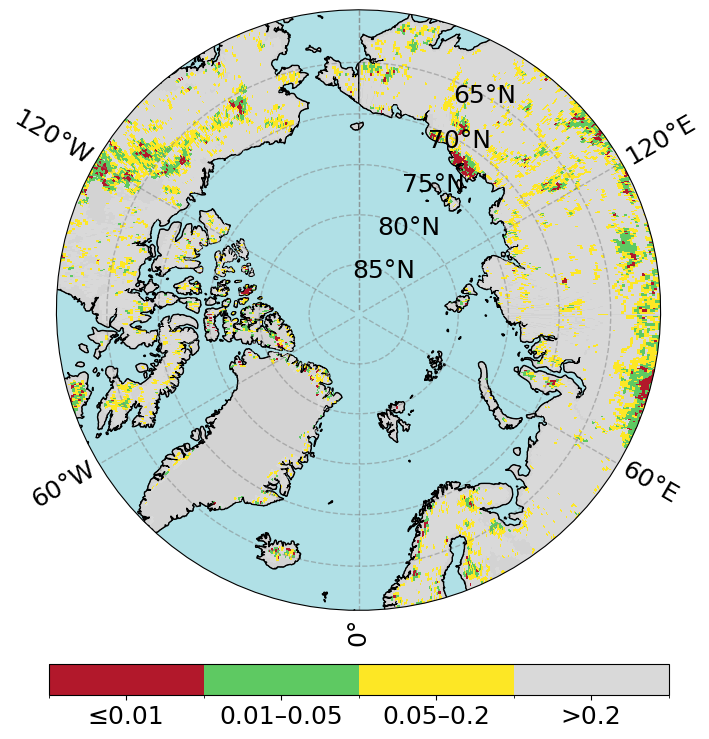

In [9]:
# Divide the pvalue into 0.01, 0.05 and 0.2
mk_p_class = np.full_like(mk_p, np.nan)

mk_p_class[mk_p <= 0.01] = 0
mk_p_class[(mk_p > 0.01) & (mk_p <= 0.05)] = 1
mk_p_class[(mk_p > 0.05) & (mk_p <= 0.2)] = 2
mk_p_class[mk_p > 0.2] = 3

color_list = [
    "#b2182b",
    "#5ec962",
    "#fde725",
    "#d9d9d9"
]

cmap = mcolors.ListedColormap(color_list)

bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
ticks = [0, 1, 2, 3]
ticklabels = ["≤0.01", "0.01–0.05", "0.05–0.2", ">0.2"]

fig, ax = plot_Northpole(
    domain_lon, domain_lat, mk_p_class,
    label_title=None,
    cmap=cmap,
    bounds=bounds,
    ticks=ticks,
    ticklabels=ticklabels
)

# Save the figure
fig.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/MOD_pvalue_map.png", dpi=300, bbox_inches="tight")
plt.close(fig)

### Figure 10a. Cluster-averaged time series of Pettitt-derived MOD over the 35-year period (1988–2022)

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/Clusterwise_trend_median_MOD_1988_2022.png


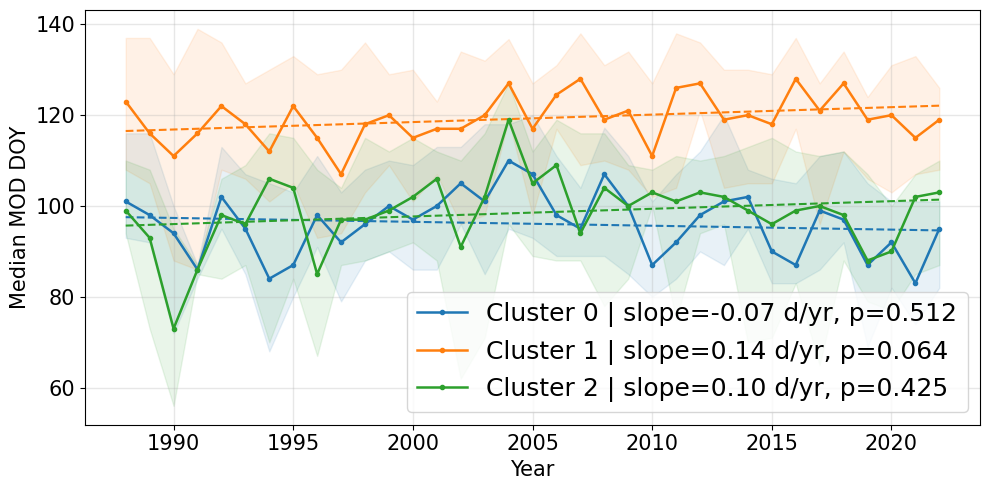

In [8]:
# Define the start and end year
start_year, end_year = 1988, 2022
min_years = 30
ny = MOD_doy.shape[2]
years = np.arange(start_year, start_year + ny)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend"


# 1. Cluster-wise median MOD with IQR and trend line
fig = plt.figure(figsize=(10, 5))
cluster_stats = {}

for cid in [0, 1, 2]:
    m = (TB_cluster == cid)

    # Mask cluster pixels
    mod_c = np.where(m[:, :, None], MOD_doy, np.nan)   # shape: (lat, lon, year)

    # Flatten spatial dimensions -> (n_pixels, n_years)
    mod_2d = mod_c.reshape(-1, ny)

    # Median and IQR by year
    median_by_year = np.nanmedian(mod_2d, axis=0)
    q25_by_year = np.nanpercentile(mod_2d, 25, axis=0)
    q75_by_year = np.nanpercentile(mod_2d, 75, axis=0)

    cluster_stats[cid] = {
        "median": median_by_year,
        "q25": q25_by_year,
        "q75": q75_by_year
    }

    # Trend statistics
    slope = sens_slope(median_by_year)
    tau, p = mann_kendall_test(median_by_year)

    # Linear trend line
    valid = np.isfinite(median_by_year)
    if np.sum(valid) >= 2:
        coef = np.polyfit(years[valid], median_by_year[valid], 1)
        trend_line = np.polyval(coef, years)
    else:
        trend_line = np.full_like(years, np.nan, dtype=float)

    # Main median line
    line, = plt.plot(
        years,
        median_by_year,
        marker="o",
        ms=3,
        linewidth=1.8,
        label=f"Cluster {cid} | slope={slope:.2f} d/yr, p={p:.3f}"
    )

    # Grey shadow: IQR
    plt.fill_between(
        years,
        q25_by_year,
        q75_by_year,
        color=line.get_color(),
        alpha=0.1,
        zorder=1
    )

    # Trend line
    plt.plot(
        years,
        trend_line,
        linestyle="--",
        linewidth=1.5,
        color=line.get_color()
    )

plt.grid(alpha=0.3)
plt.xlabel("Year")
plt.ylabel("Median MOD DOY")
# plt.title("Cluster-wise median MOD (clusters 0–2)")
plt.legend(fontsize=18)
plt.tight_layout()

# Save the figure
out_png = os.path.join(out_dir, "Clusterwise_trend_median_MOD_1988_2022.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_png)

plt.show()

## 2. MED Trend Analysis

In [9]:
# Define the start and end year
start_year, end_year = 1988, 2022
min_years = 30

if np.ma.isMaskedArray(MED_doy):
    MED_doy = MED_doy.filled(np.nan)
MED_doy = np.array(MED_doy, dtype=np.float32, copy=True)

# Exclude cluster 3 globally
MED_doy[TB_cluster == 3, :] = np.nan

# Only for DOY < 250
MED_doy[(MED_doy > 250)] = np.nan

for yi, year in enumerate(range(start_year, end_year+1)):
    bad = (load_mask_for_year(year) == 0)
    slice_y = MED_doy[:, :, yi]
    slice_y[bad] = np.nan
    MED_doy[:, :, yi] = slice_y

lat_n, lon_n = MED_doy.shape[:2]
mk_tau_med   = np.full((lat_n, lon_n), np.nan)
mk_p_med     = np.full((lat_n, lon_n), np.nan)
mk_trend_med = np.full((lat_n, lon_n), 0, dtype=np.int8)  
mk_slope_med = np.full((lat_n, lon_n), np.nan)            # Sen’s slope (days/year)

for i in range(lat_n):
    for j in range(lon_n):
        series = MED_doy[i, j, :]
        valid = ~np.isnan(series)
        if np.count_nonzero(valid) < min_years:
            continue
        try:
            res = original_test(series[valid])
            mk_tau_med[i, j]   = res.Tau
            mk_p_med[i, j]     = res.p
            mk_trend_med[i, j] = 1 if res.trend == 'increasing' else (-1 if res.trend == 'decreasing' else 0)
            mk_slope_med[i, j] = res.slope      
        except Exception:
            pass

### Figure 9b. Sen’s slope of Pettitt-derived MED, shown only for pixels significant at the 80% confidence level (p < 0.2)

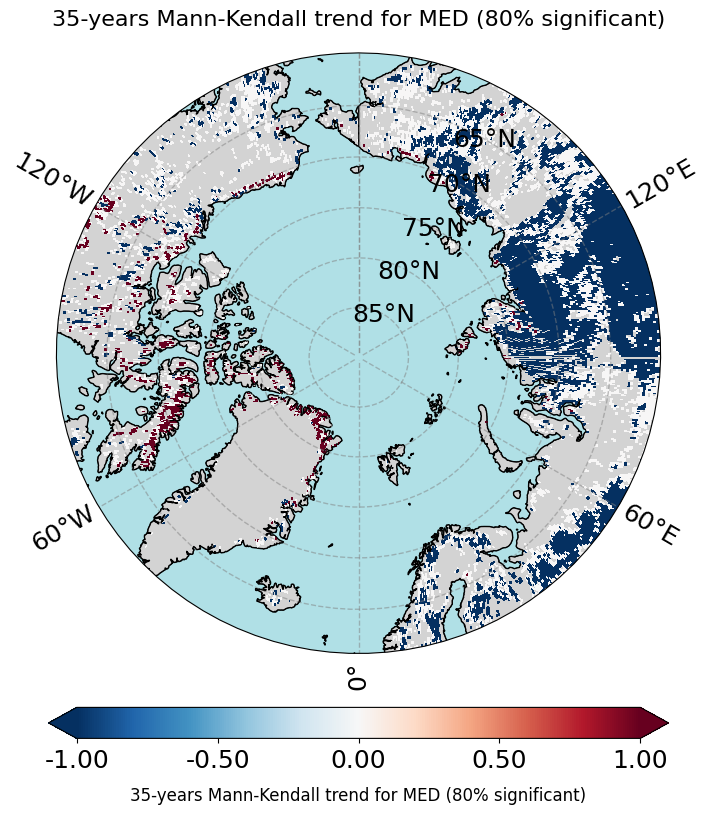

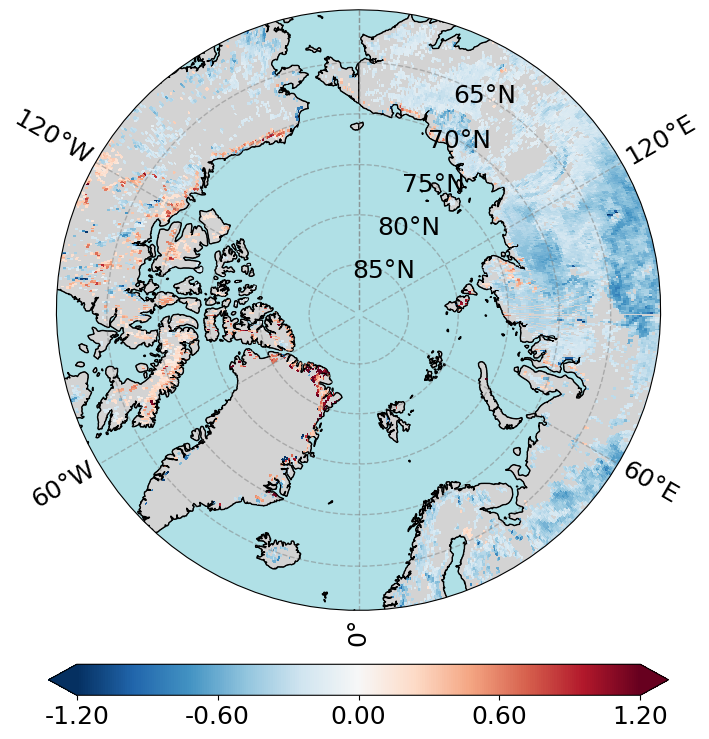

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/MED_SenSlope_80percent.png
Mean slope for 80% significant MED (days/year):  -0.2512004023146625
Median slope for 80% significant MED (days/year):  -0.2857142857142857
Total significant pixels (p < 0.2): 21017
Number of decreasing pixels: 10958
Number of increasing_pixels: 1363
Number of no-trend pixels: 8696


In [10]:
domain_lon, domain_lat = np.meshgrid(lon, lat)

# 1. Plot trend with only 80% significant level
significant_level_med = 0.2
confidence_level_med = int((1 - significant_level_med)*100)
mk_trend_significant_med = np.where(mk_p_med < significant_level_med, mk_trend_med, np.nan)
plot_Northpole(domain_lon, domain_lat, mk_trend_significant_med, label_title = f'35-years Mann-Kendall trend for MED ({confidence_level_med}% significant)', cmap='RdBu_r', vmin=-1, vmax=1, vcenter=0)

# 2. Plot slope with only 80% significant level
mk_slope_significant_med = np.where(mk_p_med < significant_level_med, mk_slope_med, np.nan)

fig_slope, ax_slope = plot_Northpole(
    domain_lon, domain_lat, mk_slope_significant_med,
    label_title=None,
    cmap="RdBu_r",
    vmin=-1.2,
    vmax=1.2,
    vcenter=0
)

# Save the figure
out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend"
out_png = os.path.join(out_dir, "MED_SenSlope_80percent.png")
fig_slope.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_png)


# Plot statistics
print(f"Mean slope for {confidence_level_med}% significant MED (days/year): ", np.nanmean(mk_slope_significant_med))
print(f"Median slope for {confidence_level_med}% significant MED (days/year): ", np.nanmedian(mk_slope_significant_med))

# Count the number of decreasing/increasing pixels
total_significant_pixels_med = np.count_nonzero(mk_p_med < significant_level_med)
decreasing_pixels_med = np.sum(mk_trend_significant_med == -1)
increasing_pixels_med = np.sum(mk_trend_significant_med == 1)
no_trend_pixels_med   = np.sum(mk_trend_significant_med == 0)

print(f"Total significant pixels (p < {significant_level_med}):", total_significant_pixels_med)
print(f"Number of decreasing pixels: {decreasing_pixels_med}")
print(f"Number of increasing_pixels: {increasing_pixels_med}")
print(f"Number of no-trend pixels: {no_trend_pixels_med}")

if total_significant_pixels_med != (decreasing_pixels_med + increasing_pixels_med + no_trend_pixels_med):
    print("Warning: Pixel count mismatch!")


### Figure 9e. Plot the p-value map, showing only statistically significant values

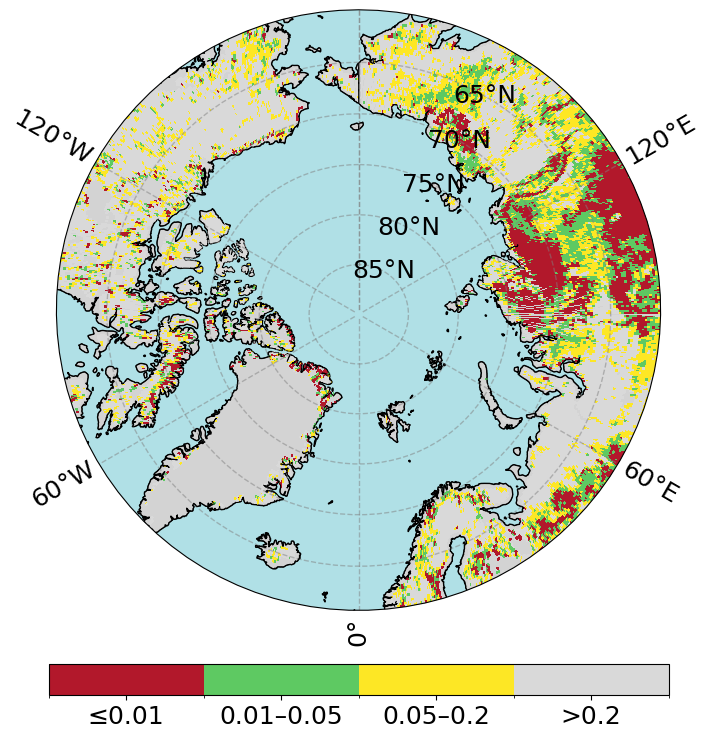

In [ ]:
# Divide the pvalue into 0.01, 0.05 and 0.2
mk_p_med_class = np.full_like(mk_p_med, np.nan)

mk_p_med_class[mk_p_med <= 0.01] = 0
mk_p_med_class[(mk_p_med > 0.01) & (mk_p_med <= 0.05)] = 1
mk_p_med_class[(mk_p_med > 0.05) & (mk_p_med <= 0.2)] = 2
mk_p_med_class[mk_p_med > 0.2] = 3

color_list = [
    "#b2182b",
    "#5ec962",
    "#fde725",
    "#d9d9d9"
]

cmap = mcolors.ListedColormap(color_list)

bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
ticks = [0, 1, 2, 3]
ticklabels = ["≤0.01", "0.01–0.05", "0.05–0.2", ">0.2"]

fig, ax = plot_Northpole(
    domain_lon, domain_lat, mk_p_med_class,
    label_title=None,
    cmap=cmap,
    bounds=bounds,
    ticks=ticks,
    ticklabels=ticklabels
)

fig.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/MED_pvalue_map.png", dpi=300, bbox_inches="tight")
plt.close(fig)


### Figure 10b. Cluster-averaged time series of Pettitt-derived MED over the 35-year period (1988–2022)

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/Clusterwise_trend_median_MED_1988_2022.png


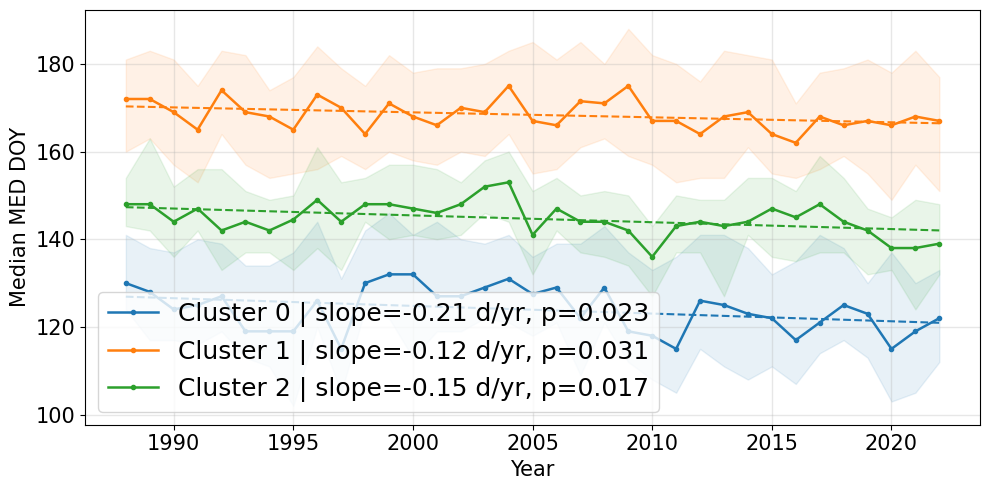

In [11]:
# Define the start and end year
start_year, end_year = 1988, 2022
min_years = 30
ny = MED_doy.shape[2]
years = np.arange(start_year, start_year + ny)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend"

# 1. Cluster-wise median MED with IQR and trend line
fig = plt.figure(figsize=(10, 5))
cluster_stats = {}

for cid in [0, 1, 2]:
    m = (TB_cluster == cid)

    # Mask cluster pixels
    med_c = np.where(m[:, :, None], MED_doy, np.nan)   # shape: (lat, lon, year)

    # Flatten spatial dimensions -> (n_pixels, n_years)
    med_2d = med_c.reshape(-1, ny)

    # Median and IQR by year
    median_by_year = np.nanmedian(med_2d, axis=0)
    q25_by_year = np.nanpercentile(med_2d, 25, axis=0)
    q75_by_year = np.nanpercentile(med_2d, 75, axis=0)

    cluster_stats[cid] = {
        "median": median_by_year,
        "q25": q25_by_year,
        "q75": q75_by_year
    }

    # Trend statistics
    slope = sens_slope(median_by_year)
    tau, p = mann_kendall_test(median_by_year)

    # Linear trend line
    valid = np.isfinite(median_by_year)
    if np.sum(valid) >= 2:
        coef = np.polyfit(years[valid], median_by_year[valid], 1)
        trend_line = np.polyval(coef, years)
    else:
        trend_line = np.full_like(years, np.nan, dtype=float)

    # Main median line
    line, = plt.plot(
        years,
        median_by_year,
        marker="o",
        ms=3,
        linewidth=1.8,
        label=f"Cluster {cid} | slope={slope:.2f} d/yr, p={p:.3f}"
    )

    # Grey shadow: IQR
    plt.fill_between(
        years,
        q25_by_year,
        q75_by_year,
        color=line.get_color(),
        alpha=0.1,
        zorder=1
    )

    # Trend line
    plt.plot(
        years,
        trend_line,
        linestyle="--",
        linewidth=1.5,
        color=line.get_color()
    )

plt.grid(alpha=0.3)
plt.xlabel("Year")
plt.ylabel("Median MED DOY")
# plt.title("Cluster-wise median MOD (clusters 0–2)")
plt.legend(fontsize=18)
plt.tight_layout()

# Save the figure
out_png = os.path.join(out_dir, "Clusterwise_trend_median_MED_1988_2022.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_png)

plt.show()


## 3. Melt Duration (MED - MOD) Trend Analysis 

In [12]:
# Define the start and end year
start_year, end_year = 1988, 2022
min_years = 30

# Exclude cluster 3 
MOD_doy[TB_cluster == 3, :] = np.nan
MED_doy[TB_cluster == 3, :] = np.nan

# Exclude DOY < 30 and DOY > 250 for MOD, and DOY > 250 for MED
MOD_doy[(MOD_doy < 30) | (MOD_doy > 250)] = np.nan
MED_doy[MED_doy > 250] = np.nan
invalid_mask = np.isnan(MOD_doy) | np.isnan(MED_doy)
MOD_doy[invalid_mask] = np.nan
MED_doy[invalid_mask] = np.nan

Duration_doy = MED_doy - MOD_doy

for yi, year in enumerate(range(start_year, end_year+1)):
    bad = (load_mask_for_year(year) == 0)
    slice_y = Duration_doy[:, :, yi]
    slice_y[bad] = np.nan
    Duration_doy[:, :, yi] = slice_y

lat_n, lon_n = Duration_doy.shape[:2]
mk_tau_duration   = np.full((lat_n, lon_n), np.nan)
mk_p_duration     = np.full((lat_n, lon_n), np.nan)
mk_trend_duration = np.full((lat_n, lon_n), 0, dtype=np.int8)  
mk_slope_duration = np.full((lat_n, lon_n), np.nan)            # Sen’s slope (days/year)

for i in range(lat_n):
    for j in range(lon_n):
        series = Duration_doy[i, j, :]
        valid = ~np.isnan(series)
        if np.count_nonzero(valid) < min_years:
            continue
        try:
            res = original_test(series[valid])
            mk_tau_duration[i, j]   = res.Tau
            mk_p_duration[i, j]     = res.p
            mk_trend_duration[i, j] = 1 if res.trend == 'increasing' else (-1 if res.trend == 'decreasing' else 0)
            mk_slope_duration[i, j] = res.slope      
        except Exception:
            pass

### Figure 9c. Sen’s slope of Pettitt-derived Melt Duration, shown only for pixels significant at the 80% confidence level (p < 0.2)

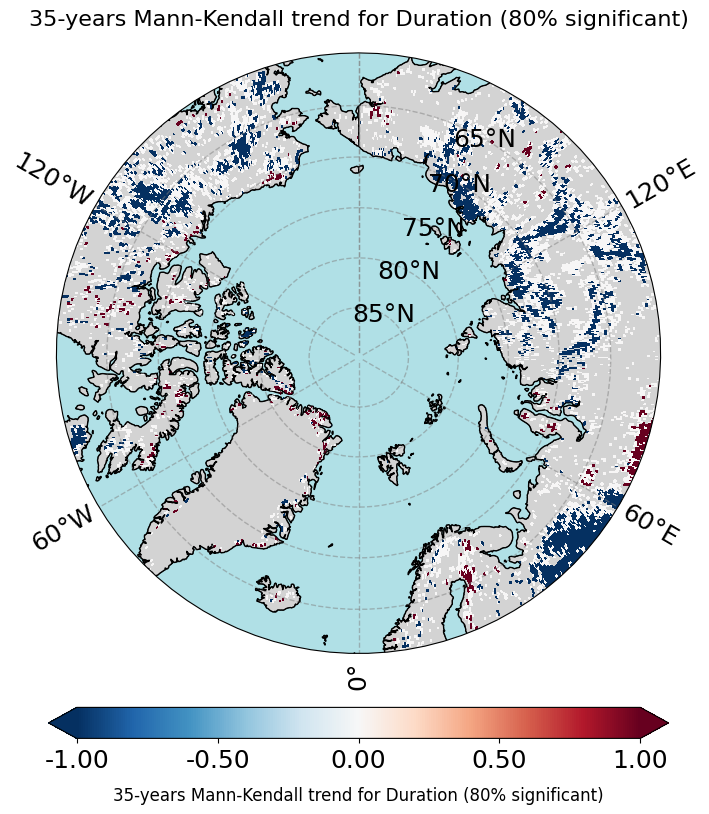

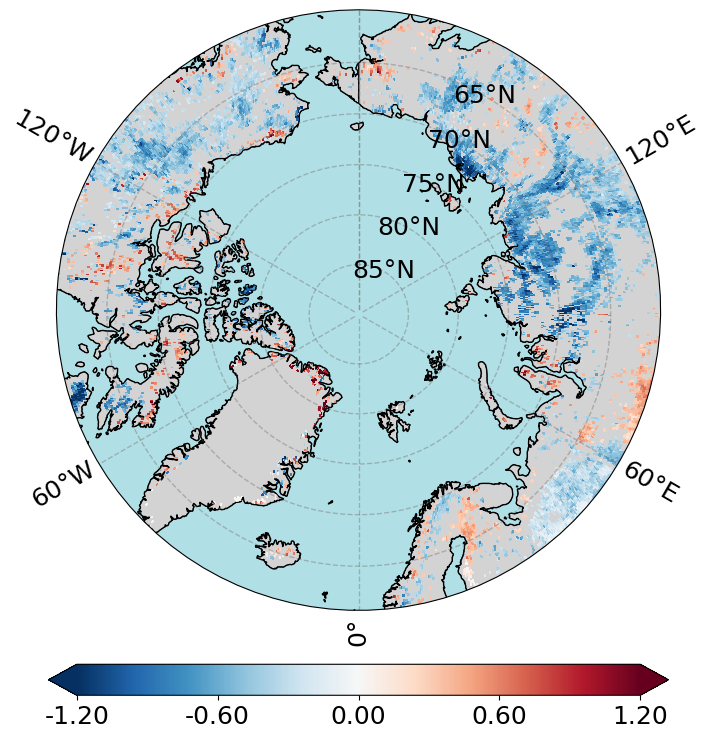

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/Pettitt_Duration_SenSlope_80percent.png
Mean slope for Duration (MED - MOD) (days/year):  -0.35570784240448833
Median slope for Duration (MED - MOD) (days/year):  -0.4583333333333333
Total significant pixels (p < 0.2): 14620
Number of decreasing pixels:  5098
Number of increasing_pixels:  912
Number of no trend pixels:  8610


In [13]:
domain_lon, domain_lat = np.meshgrid(lon, lat)

# 1. Plot trend with only 80% significant trend
significant_level_duration = 0.2
confidence_level_duration = int((1 - significant_level_duration)*100)
mk_trend_significant_duration = np.where(mk_p_duration < significant_level_duration, mk_trend_duration, np.nan)
plot_Northpole(domain_lon, domain_lat, mk_trend_significant_duration, label_title = f'35-years Mann-Kendall trend for Duration ({confidence_level_duration}% significant)', cmap='RdBu_r', vmin=-1, vmax=1, vcenter=0)

# 2. Plot slope with only 80% significant trend
mk_slope_significant_duration = np.where(mk_p_duration < significant_level_duration, mk_slope_duration, np.nan)
fig_slope, ax_slope = plot_Northpole(
    domain_lon, domain_lat, mk_slope_significant_duration,
    label_title=None,
    cmap="RdBu_r",
    vmin=-1.2,
    vmax=1.2,
    vcenter=0
)

# Save the figure
out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend"
out_png = os.path.join(out_dir, "Pettitt_Duration_SenSlope_80percent.png")
fig_slope.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_png)


# Plot statistics
print("Mean slope for Duration (MED - MOD) (days/year): ", np.nanmean(mk_slope_significant_duration))
print("Median slope for Duration (MED - MOD) (days/year): ", np.nanmedian(mk_slope_significant_duration))

# Count the number of decreasing/increasing pixels
total_significant_pixels_duration = np.count_nonzero(mk_p_duration < significant_level_duration)
decreasing_pixels = np.sum(mk_trend_significant_duration == -1)
increasing_pixels = np.sum(mk_trend_significant_duration == 1)
no_trend_pixels   = np.sum(mk_trend_significant_duration == 0)

print("Total significant pixels (p < 0.2):", total_significant_pixels_duration)
print("Number of decreasing pixels: ", decreasing_pixels)
print("Number of increasing_pixels: ", increasing_pixels)
print("Number of no trend pixels: ", no_trend_pixels)

if total_significant_pixels_duration != (decreasing_pixels + increasing_pixels + no_trend_pixels):
    print("Total significant pixels (p < 0.2) is not equal to the sum of decreasing/increasing/no trend pixels")


### Figure 9f. Plot the p-value map, showing only statistically significant values

In [ ]:
# Divide the pvalue into 0.01, 0.05 and 0.2
mk_p_duration_class = np.full_like(mk_p_duration, np.nan)

mk_p_duration_class[mk_p_duration <= 0.01] = 0
mk_p_duration_class[(mk_p_duration > 0.01) & (mk_p_duration <= 0.05)] = 1
mk_p_duration_class[(mk_p_duration > 0.05) & (mk_p_duration <= 0.2)] = 2
mk_p_duration_class[mk_p_duration > 0.2] = 3

color_list = [
    "#b2182b",
    "#5ec962",
    "#fde725",
    "#d9d9d9"
]

cmap = mcolors.ListedColormap(color_list)

bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
ticks = [0, 1, 2, 3]
ticklabels = ["≤0.01", "0.01–0.05", "0.05–0.2", ">0.2"]

fig, ax = plot_Northpole(
    domain_lon, domain_lat, mk_p_duration_class,
    label_title=None,
    cmap=cmap,
    bounds=bounds,
    ticks=ticks,
    ticklabels=ticklabels
)

# Save the figure
fig.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/Duration_pvalue_map.png", dpi=300, bbox_inches="tight")
plt.close(fig)

### Figure 10c. Cluster-averaged time series of Pettitt-derived Melt Duration over the 35-year period (1988–2022)

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/Clusterwise_trend_median_Duration_1988_2022.png


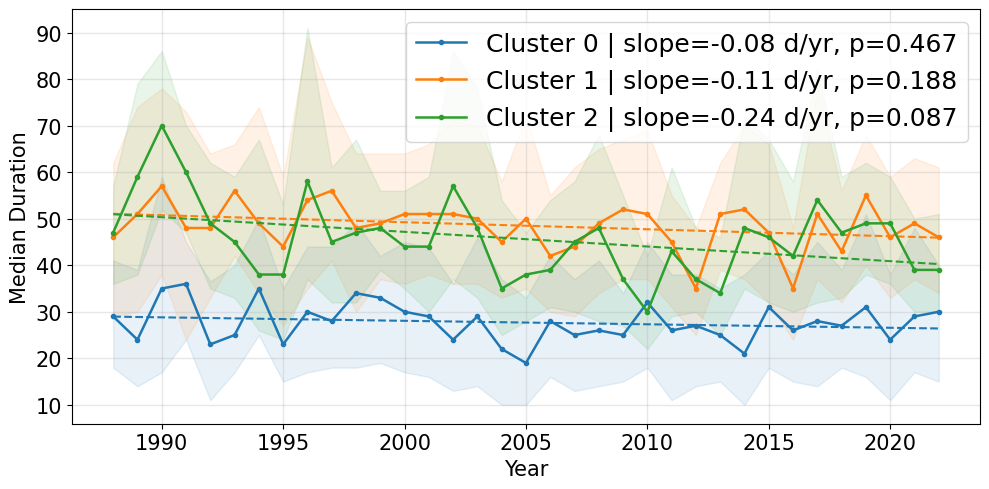

In [14]:
# Define the start and end year
start_year, end_year = 1988, 2022
min_years = 30
ny = Duration_doy.shape[2]
years = np.arange(start_year, start_year + ny)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend"


# 1. Cluster-wise median Melt Duration with IQR and trend line
fig = plt.figure(figsize=(10, 5))
cluster_stats = {}

for cid in [0, 1, 2]:
    m = (TB_cluster == cid)

    # Mask cluster pixels
    duration_c = np.where(m[:, :, None], Duration_doy, np.nan)   # shape: (lat, lon, year)

    # Flatten spatial dimensions -> (n_pixels, n_years)
    duration_2d = duration_c.reshape(-1, ny)

    # Median and IQR by year
    median_by_year = np.nanmedian(duration_2d, axis=0)
    q25_by_year = np.nanpercentile(duration_2d, 25, axis=0)
    q75_by_year = np.nanpercentile(duration_2d, 75, axis=0)

    cluster_stats[cid] = {
        "median": median_by_year,
        "q25": q25_by_year,
        "q75": q75_by_year
    }

    # Trend statistics
    slope = sens_slope(median_by_year)
    tau, p = mann_kendall_test(median_by_year)

    # Linear trend line
    valid = np.isfinite(median_by_year)
    if np.sum(valid) >= 2:
        coef = np.polyfit(years[valid], median_by_year[valid], 1)
        trend_line = np.polyval(coef, years)
    else:
        trend_line = np.full_like(years, np.nan, dtype=float)

    # Main median line
    line, = plt.plot(
        years,
        median_by_year,
        marker="o",
        ms=3,
        linewidth=1.8,
        label=f"Cluster {cid} | slope={slope:.2f} d/yr, p={p:.3f}"
    )

    # Grey shadow: IQR
    plt.fill_between(
        years,
        q25_by_year,
        q75_by_year,
        color=line.get_color(),
        alpha=0.1,
        zorder=1
    )

    # Trend line
    plt.plot(
        years,
        trend_line,
        linestyle="--",
        linewidth=1.5,
        color=line.get_color()
    )

plt.grid(alpha=0.3)
plt.xlabel("Year")
plt.ylabel("Median Duration")
# plt.title("Cluster-wise median Melt Duration (clusters 0–2)")
plt.legend(fontsize=18)
plt.tight_layout()

# Save the figure
out_png = os.path.join(out_dir, "Clusterwise_trend_median_Duration_1988_2022.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_png)

plt.show()